# Module 5, Class 3: PCA on Mall Customers

**Student:** Firdavs Boliev

This notebook uses PCA to reduce customer features into a smaller number of dimensions and interpret the main components.


## 0. Setup

In [1]:
# Import data, plotting, scaling, and PCA tools.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

print("Setup complete.")


Setup complete.


## 1. Load Mall Customers Dataset

In [2]:
# Load Mall Customers data, using a deterministic fallback if the public URL is unavailable.
url = "https://raw.githubusercontent.com/dsrscientist/dataset1/master/Mall_Customers.csv"

try:
    df = pd.read_csv(url)
    print("Loaded Mall Customers from the public URL.")
except Exception:
    print("Public Mall Customers URL unavailable. Generating a small Mall-like dataset.")
    rng = np.random.default_rng(42)
    segments = [
        ("Male", 24, 30, 75, 40),
        ("Female", 26, 32, 80, 40),
        ("Male", 52, 85, 22, 40),
        ("Female", 45, 82, 28, 40),
        ("Female", 39, 60, 50, 40),
    ]
    rows = []
    for gender, age_mean, income_mean, spend_mean, n in segments:
        for _ in range(n):
            rows.append({
                "CustomerID": len(rows) + 1,
                "Gender": gender if rng.random() < 0.75 else ("Female" if gender == "Male" else "Male"),
                "Age": int(np.clip(rng.normal(age_mean, 6), 18, 70)),
                "Annual Income (k$)": int(np.clip(rng.normal(income_mean, 10), 15, 140)),
                "Spending Score (1-100)": int(np.clip(rng.normal(spend_mean, 12), 1, 100)),
            })
    df = pd.DataFrame(rows)

print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print("\nFirst 5 rows:")
df.head()


Public Mall Customers URL unavailable. Generating a small Mall-like dataset.
Shape: (200, 5)

Columns: ['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

First 5 rows:


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Female,18,37,86
1,2,Male,18,31,71
2,3,Male,18,38,84
3,4,Male,30,34,64
4,5,Male,18,38,74


In [3]:
# Encode Gender and choose the numeric features for PCA.
# Select numeric features for PCA
# Encode Gender as 0/1
df['Gender_encoded'] = (df['Gender'] == 'Male').astype(int)

features = ['Gender_encoded', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']
X = df[features].copy()

print("Features for PCA:")
print(X.describe().round(2))


Features for PCA:
       Gender_encoded     Age  Annual Income (k$)  Spending Score (1-100)
count          200.00  200.00              200.00                  200.00
mean             0.41   36.59               56.84                   50.55
std              0.49   11.39               25.76                   25.92
min              0.00   18.00               15.00                    1.00
25%              0.00   26.00               32.00                   30.00
50%              0.00   37.00               58.00                   49.00
75%              1.00   46.00               80.25                   73.00
max              1.00   62.00              107.00                  100.00


## 2. Standardize Features

PCA is sensitive to feature scale — features with larger ranges will dominate the principal components.

In [4]:
# Standardize the features so PCA is not dominated by large numeric ranges.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("After scaling (mean ~ 0, std ~ 1):")
print(pd.DataFrame(X_scaled, columns=features).describe().round(2))


After scaling (mean ~ 0, std ~ 1):
       Gender_encoded     Age  Annual Income (k$)  Spending Score (1-100)
count          200.00  200.00              200.00                  200.00
mean             0.00   -0.00                0.00                    0.00
std              1.00    1.00                1.00                    1.00
min             -0.83   -1.64               -1.63                   -1.92
25%             -0.83   -0.93               -0.97                   -0.79
50%             -0.83    0.04                0.05                   -0.06
75%              1.20    0.83                0.91                    0.87
max              1.20    2.24                1.95                    1.91


## 3. PCA with All Components

In [5]:
# Fit PCA with all components and print how much variance each component explains.
pca_full = PCA(n_components=4)
X_pca_full = pca_full.fit_transform(X_scaled)

print("Explained Variance Ratio per Component:")
for i, var in enumerate(pca_full.explained_variance_ratio_):
    print(f"  PC{i+1}: {var:.4f} ({var*100:.1f}%)")

print(f"\nTotal explained variance: {pca_full.explained_variance_ratio_.sum()*100:.1f}%")


Explained Variance Ratio per Component:
  PC1: 0.6466 (64.7%)
  PC2: 0.2495 (25.0%)
  PC3: 0.0606 (6.1%)
  PC4: 0.0433 (4.3%)

Total explained variance: 100.0%


## 4. Scree Plot

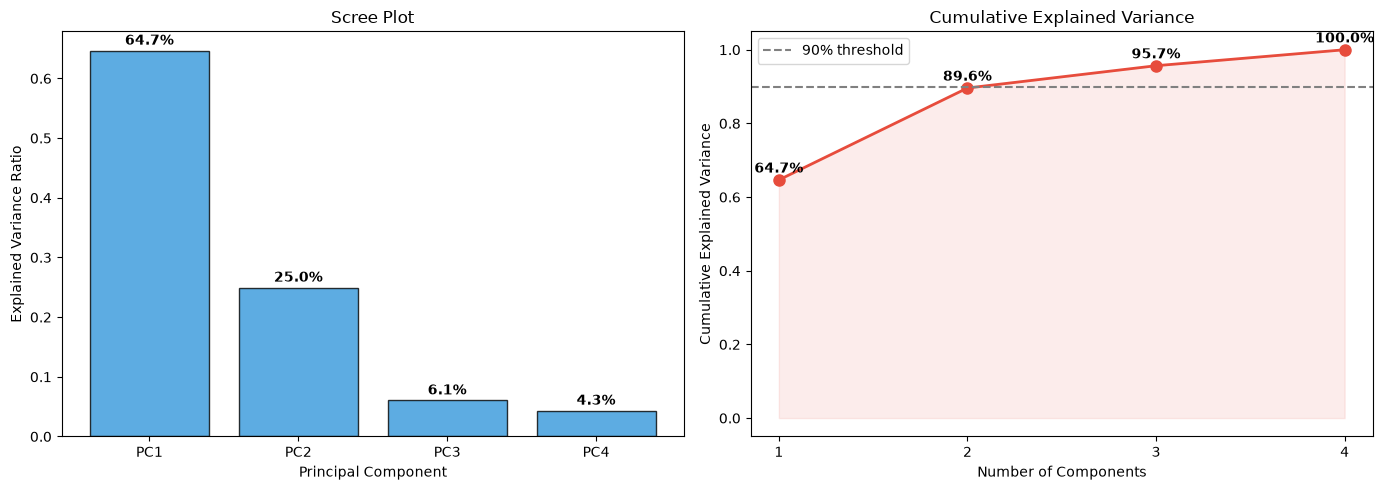

In [6]:
# Plot individual and cumulative explained variance.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

components = range(1, 5)
var_ratio = pca_full.explained_variance_ratio_
cumulative = np.cumsum(var_ratio)

# Scree plot
axes[0].bar(components, var_ratio, color='#3498db', alpha=0.8, edgecolor='black')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Scree Plot')
axes[0].set_xticks(list(components))
axes[0].set_xticklabels([f'PC{i}' for i in components])
for i, v in enumerate(var_ratio):
    axes[0].text(i+1, v + 0.01, f'{v:.1%}', ha='center', fontweight='bold')

# Cumulative explained variance
axes[1].plot(components, cumulative, 'o-', color='#e74c3c', linewidth=2, markersize=8)
axes[1].axhline(y=0.9, color='gray', linestyle='--', label='90% threshold')
axes[1].fill_between(components, cumulative, alpha=0.1, color='#e74c3c')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Explained Variance')
axes[1].set_xticks(list(components))
axes[1].legend()
for i, v in enumerate(cumulative):
    axes[1].text(i+1, v + 0.02, f'{v:.1%}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


## 5. Reduce to 2 Components and Scatter Plot

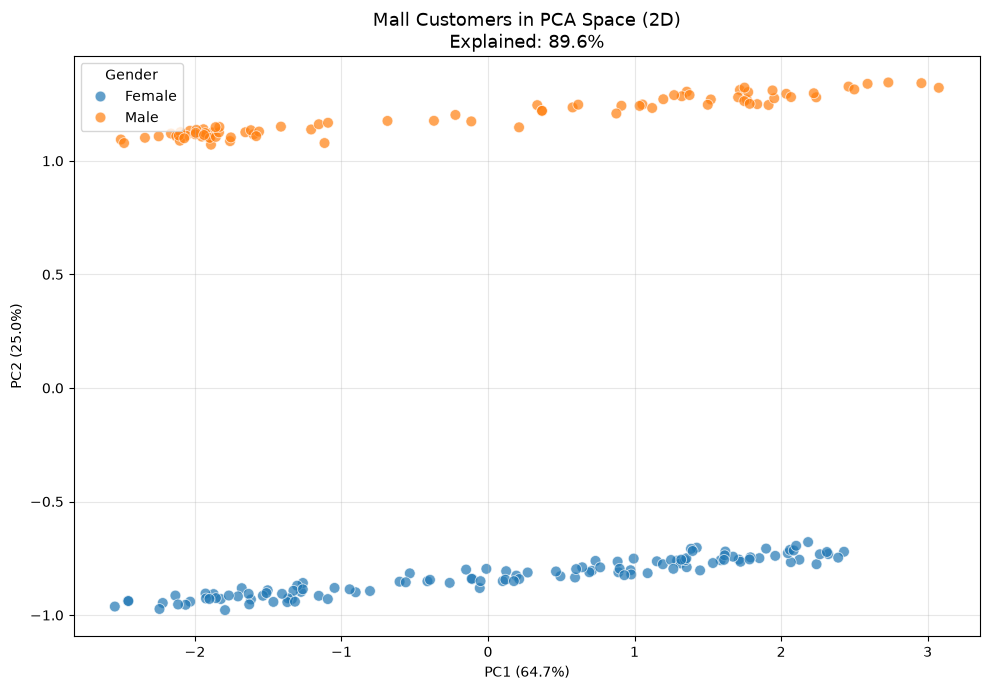

In [7]:
# Reduce the data to two principal components and plot the customers.
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca_2d, columns=['PC1', 'PC2'])
pca_df['Gender'] = df['Gender'].values

plt.figure(figsize=(10, 7))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Gender', alpha=0.7, s=60)
plt.title(f'Mall Customers in PCA Space (2D)\nExplained: {pca_2d.explained_variance_ratio_.sum()*100:.1f}%', fontsize=13)
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 6. PCA Loadings

Loadings tell us how much each original feature contributes to each principal component.

PCA Loadings (how original features map to components):
                           PC1     PC2     PC3     PC4
Gender_encoded         -0.0478  0.9977  0.0452 -0.0172
Age                     0.5715 -0.0123  0.7461 -0.3413
Annual Income (k$)      0.5846  0.0454 -0.0782  0.8063
Spending Score (1-100) -0.5739 -0.0490  0.6597  0.4828



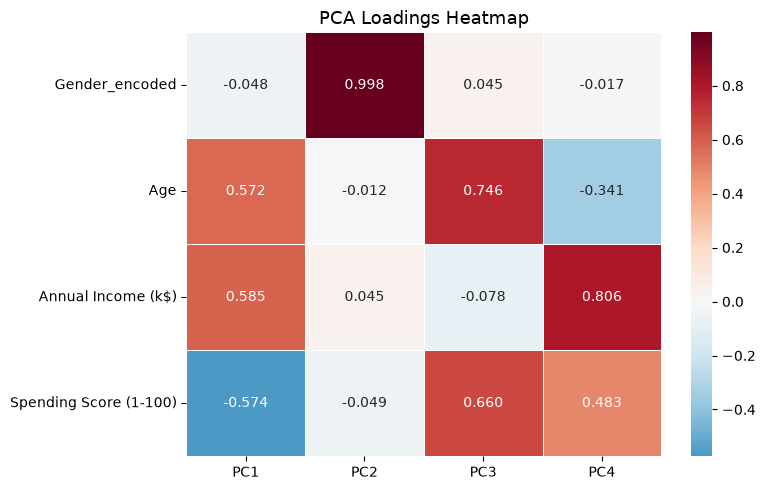

In [8]:
# Create and plot PCA loadings to understand each component.
loadings = pd.DataFrame(
    pca_full.components_.T,
    columns=[f'PC{i+1}' for i in range(4)],
    index=features
)

print("PCA Loadings (how original features map to components):")
print(loadings.round(4))
print()

# Heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(loadings, annot=True, fmt='.3f', cmap='RdBu_r', center=0, linewidths=0.5)
plt.title('PCA Loadings Heatmap', fontsize=13)
plt.tight_layout()
plt.show()


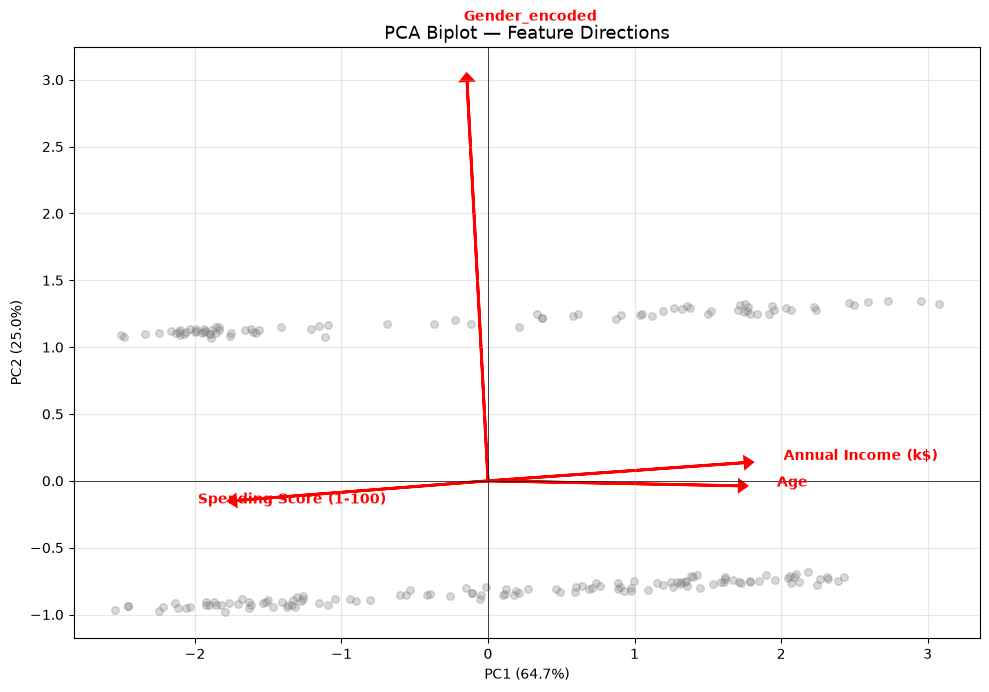

In [9]:
# Draw a biplot so feature directions are visible in PCA space.
# Biplot: vectors showing feature directions in PC1-PC2 space
plt.figure(figsize=(10, 7))

# Scatter points
plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], alpha=0.3, s=30, color='gray')

# Feature vectors
scale = 3  # Scale arrows for visibility
for i, feat in enumerate(features):
    plt.arrow(0, 0,
              loadings.iloc[i, 0] * scale,
              loadings.iloc[i, 1] * scale,
              head_width=0.08, head_length=0.05, fc='red', ec='red', linewidth=2)
    plt.text(loadings.iloc[i, 0] * scale * 1.15,
             loadings.iloc[i, 1] * scale * 1.15,
             feat, fontsize=10, fontweight='bold', color='red')

plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('PCA Biplot — Feature Directions', fontsize=13)
plt.axhline(y=0, color='black', linewidth=0.5)
plt.axvline(x=0, color='black', linewidth=0.5)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 7. Interpret the Principal Components

Look at the loadings table and biplot above, then answer:

1. **PC1 interpretation:** Which original features contribute most to PC1? What does PC1 represent in business terms? (e.g., does it separate rich vs poor customers? young vs old?)

2. **PC2 interpretation:** Which features dominate PC2? What business meaning does this axis carry?

3. How many components would you keep if you wanted to retain at least 90% of the variance?

### PCA Interpretation Answer

PC1 is mostly driven by **Age**, **Annual Income**, and **Spending Score**. In this data, it separates customers with higher age/income and lower spending from customers with lower age/income and higher spending.

PC2 is mostly driven by **Gender_encoded**, so it mainly separates male and female customers in the encoded feature space.

To keep at least 90% of the variance, I would keep **3 components**. The first two components explain close to 90%, but the third component pushes the cumulative explained variance safely above the 90% target.


---
## Summary

| Concept | Details |
|---------|--------|
| PCA | Projects data onto directions of maximum variance |
| Standardization | Required before PCA — features must be on the same scale |
| Scree Plot | Shows variance per component — look for the "elbow" |
| Cumulative Variance | Helps decide how many components to keep (e.g., 90% threshold) |
| Loadings | Coefficients mapping original features to principal components |
| Biplot | Overlays feature vectors on the PCA scatter — shows feature directions |